# Modeling: MultiModal AI — Homework 3
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore Vision-Language Models (VLMs) and gain hands-on experience fine-tuning one.

---

## Environment Setup

Go to the top menu:  
Runtime → Change runtime type → Hardware accelerator → Choose "A100"

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:  
https://colab.research.google.com/signup


# Part 1: Reading & Reflection (20 points)

### Required Reading
[Multimodal Few-Shot Learning with Frozen Language Models](https://arxiv.org/pdf/2106.13884)

[Quality Not Quantity: On the Interaction between Datase Design and Robustness of CLIP
](https://arxiv.org/pdf/2208.05516.pdf)

[Generative AI: Here to stay, but for good?](https://www.sciencedirect.com/science/article/pii/S0160791X2300177X)

---

### Questions
1. What types of multimodal data noise are typically present in multimodal datasets, and how can they negatively impact the performance of a model during training? Can you provide examples of multimodal data points that might be considered noisy? Furthermore, how might we develop estimators capable of distinguishing between noisy and noise-free multimodal data pairs? If you have unlimited fundings to use for data filtering and data cleaning, what would be the ideal way to clean the multimodal dataset?

2. What is the intuition of utilizing frozen large language models as the backbone for multimodal tasks? Which types of encoders would facilitate the integration of diverse information into a format understandable by LLMs? How do these LLMs process and interpret information from different modalities?

3. Ensuring the effectiveness of multimodal foundation models through high-quality instruction tuning is vital. A study detailed at [here](https://arxiv.org/pdf/2402.04333.pdf) introduces a strategy for selecting significant data specifically suited for enhancing instruction tuning for language models. A primary challenge in this approach is determining which data are most crucial for targeted instruction tuning. How can we accurately identify and select the most impactful data for enhancing instruction tuning in multimodal foundation models? Given the complexity of diverse and multimodal information, what strategies can ensure the effectiveness of instruction tuning data for specific tasks?

4. With the advancement of generative AI, distinguishing between AI-generated and human-created content is becoming increasingly challenging. Besides watermarking, which has its limitations, are there other effective methods to differentiate between AI-generated and human-created content across various modalities (text, audio, video, image)? Or is it becoming virtually impossible to make this distinction?

5. For state-of-the-art video generation models like Sora, Yann Lecun mentioned in [here](https://twitter.com/ylecun/status/1758740106955952191) that Sora does not understand the real world and its corresponding physical rules. Do you agree with this view? Can the future development of generative AI systems truly incorporate real-world knowledge, or are they limited in this aspect? Is pursuing generative AI a viable path towards achieving Artificial General Intelligence (AGI)?


Answers:

1. First, any type of unimodal noise can be a problem. As in *Quality Not Quantity*, common issues include adversarial examples or corruptions (Gaussian noise or blur for images). Other examples for vision include defocus/bokeh, JPEG/compression/digitizing artifacts, motion blur, while examples for text include typos, false cognates, poor word choice, etc. Obviously, such unimodal noise can reduce modality encoder accuracy.

A more common and insidious case: multimodal noise, where the corruption is not limited to a single modality. Notice equivalent corruption to both modalities is generally a non-issue; methods like ambient diffusion and learning from noisy data can still align and fuse correctly (though of course accuracy is worse than with clean data). Even if one modality is corrupted and the other clean, the model may be able to recover clean internal representations with sufficient data (central limit theorem). Unfortunately, most often the corruption in one modality is paired with a different corruption in the other modality---which, like the curse of dimensionality, can scale exponentially with the number of modalities (making central limit theorem difficult to apply). An example might include a blurred image with an incorrect (not simply vague) caption.

One approach (from *Quality Not Quantity*) considers alignment. Essentially, models pretrained on individual modalities should be most invariant to a change in modality (a distribution shift). So the cleanest data under this model is the data with the most consistent information across modalities (and of course smaller sub-distributions to ensure sufficient sampling).

Given unlimited funding/infinite compute, this translates to filtering each modality with a teacher model, which estimates alignment for different samples (and subselects for higher alignment). Then the student model can be pretrained on the high-alignment subset (so it has a cleaner curriculum to learn), after which it replaces the teacher model and we iterate.
If using an ensemble of models for different modalities, the ensemble output is a predictor of the alignment and thus the lack of noise in the dataset---so this can be used for a stopping criterion.

One consideration: repeated subsampling may decrease overall training-set diversity; we want maximum information (mutual information = alignment in this case) for a particular fixed variance (training set diversity), so care must be taken to retain diverse samples.

2. From the *Frozen* paper, fine-tuning the languange model is risky due to data imbalance; the fine-tuning dataset (paired image-caption data) is much smaller than the original text corpus. Further, an off-the-shelf language model is readily available, modular, and somewhat generic; LLMs are somewhat general-purpose computing in modern ML. To encode, tokenizers are quite common. Just train an encoder and quantize to a discrete token (preferably with a text-contrastive approach like CLIP, to align to text), and the LLM will be able to process it. One disadvantage of current LLMs (rapidly changing with discrete-diffusion) includes the autoregressive generation, as this imposes a sequential dependence among the tokens. On the other hand, we can do simple pattern-matching / online adaptation relatively easily with the autoregressive structure (just provide paired examples as prior tokens).

3. The *LESS* approach selects samples with gradients from a warmup LORA training that most match those from validation data. More generally, we want samples with the maximum new information; *LESS* just estimates the score (grad log p, or equivalently here the active subspace) using the validation distribution. There are a lot of similar methods from general ML, information theory, and reduced order modeling community: some examples would be optimal experiment design (OED, via Bayes law), community detection with the strong data-processing-inequality (SDPI)...but most of them rely on some approximation to the score. For multimodal models, one approach would essentially take the approach in #1 for cleaning data, but instead of alignment across distributions, we would require alignment to either the target distribution or a high-quality teacher model.

Of course, a simple approach would involve just using CLIP or other contrastive encoders (or even just PCA across multiple modalities) to provide a cheap, approximate score directly.

Some strategies that help ensure the effectiveness of instruction tuning: as in *Frozen*, make sure the multimodal tokenizers all align with the instruction and text token format (and align semantically as well). Few-shot (or at least one-shot) prompting also helps the model understand the instruction, leveraging the autoregressive structure.

4. Actually a rather simple question to answer, as we just want to measure the difference between the generated and true distributions. There are a lot of ways to do this, and a lot of ways to fail too. For example, as in *Generative AI*, an enduring difference is the limited (likely historical) information given to the generative model: assuming the training distribution is known, community detection can be used to identify true images (which are out-of-distribution with respect to the generative / training distribution). Some examples of this could include historical biases present in current datasets. Recent work by Adam Klivans and others suggest that simply computing the different moments of each distribution with limited samples can allow you to separate them. Of course, a per-sample basis can still be indistinguishable, as it is possible for even a badly-trained model to just memorize a training sample. 
And currently, at least for images, we know the perception/fidelity metrics are flawed (FID) and incomplete.


5. As always, there are arguments for both directions. Simply from the bitter lesson/scaling arguments, we know that with enough data, a large enough model, and the right loss/optimizer combination, even a simple generative model can become a world model. This is not just true for ML models; even physical (PDE) equations can be reformulated as minimization objectives for the action (the Lagrangian action). With enough data, the right loss will provide some supervision on the action, so the model will converge to true physics as best possible for the architecture (modulo optimizer, of course). On the other hand, there's always an undersampling problem with such a formulation. To avoid this, we add inductive biases, so the model doesn't just memorize some well-sampled regions. Arguments such as LeCun's fall in this category; they say we require better representations that create the right manifold (essentially construct the right inductive biases). For scaling/gen-ai groups, AGI is actually a perpetual improvement as they keep trying to better sample reality. It's similarly possible that the right manifold (for everything) doesn't exist in simple closed form (i.e. easily representable with an ML model).

# Part 2: Testing and Fine-tuning VLMs (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.  
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.  
- The **secret word** displayed by your verification cell.

---

In [1]:
from ipywidgets import Widget
Widget.widget_types

/tmp/ipykernel_2836087/1277537672.py:2: DeprecationWarning: Widget.widget_types is deprecated.
  Widget.widget_types


In [1]:
!uv pip install transformers accelerate bitsandbytes pillow torch -q

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 42
cipher_bytes = [99, 10, 102, 101, 124, 111, 10, 103, 103, 107, 99]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = torch.bitwise_xor(cipher, KEY)
    torch.cuda.synchronize()
    secret = bytes(decoded.tolist()).decode("ascii")
    print("SECRET_WORD:", secret)
else:
    print("SECRET_WORD: (not on GPU)")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA L40S
SECRET_WORD: I LOVE MMAI


# Problem 2: Prepare Your Dataset (20 points)

## **PLEASE READ THIS ENTIRE SECTION BEFORE PROCEDING**

For Problem 2, you will **use the dataset you have collected from Homework 1 and Homework 2 or a completely new one if you prefer** to fine-tune a Vision-Language Model (VLM).

Even if your original data isn't image-based (e.g. it's audio, time-series, or text), you should find a way to **visualize it** meaningfully. The dataset you prepare will serve as the foundation for model fine-tuning in later steps.

---

### How to Convert Your Project Data Into Images

**If your project is not originally image-based, consider these ideas to generate visual input:**

| Data Type                    | Visual Representation Example                          |
|-----------------------------|---------------------------------------------------------|
| Time-series / sensor data   | Line plots or multi-panel charts (with axis labels)     |
| Audio / Music / Physiology  | Spectrograms or waveform plots                         |
| 3d data (point clouds, CAD) | Rendering/splicing into 2D images

You are encouraged to be **creative and domain-specific** in your visualizations.

**You will need to explore ways to convert your data into images if it does not already consist of this modality. Research on your own and come up with the needed code to do so. If you are still stuck on figuring this out, please reach out to a TA for help!**

### Download Example Training Data

The next block of code will download an example dataset and create a folder named `mmai-data/`.  
Inside this folder, you will find:

```
mmai-data/
├── images/
│   ├── 1.jpg
│   └── 2.jpg
└── data.jsonl
```

The file `data.jsonl` contains your training annotations.  
Each line represents one training example with the following fields:

```json
{
  "image": "images/1.jpg",
  "question": "List objects you see.",
  "answer": "cat, sofa, blanket, remote, cushion"
}
```

---

### Your Task

Now, prepare your own dataset following the same structure as the example.


Example structure:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   ├── image_02.jpg
│   ├── ...
└── data.jsonl
```

As part of this task. You should split the data into a train and test split. **The test split should consist of the images of data that you will not use in training.**


Answer:
We will try to answer two questions together --- what is the absolute simulation time of the image (i.e. how far from the Gaussian noise initialization is it) and what is the local intrinsic dimensionality of the manifold (computed using the TwoNN method below).

In [2]:
from torch.utils.data import DataLoader, random_split
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
backend = matplotlib.get_backend()
import jpcm.draw as draw
matplotlib.use(backend)
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_dct as dct
from tqdm import tqdm

In [3]:
data = '/orcd/home/002/a1744874/orcd/pool/ml/datasets/forced_turbulence/v1_20260216_8ec01795/forced_turbulence.npy'
dataset = torch.from_numpy(np.load(data, mmap_mode='r')[:,1:-2,:1,:,:])
print(dataset.shape)

torch.Size([20, 498, 1, 512, 512])


In [4]:
import torch

def intrinsic_dimension_twoNN(data, chunk=498, downsample=1):
    """
    data shape: (B, T, 1, H, W)

    returns:
        dims: (B, T)
    """

    # optional spatial downsample
    data = data[...,::downsample, ::downsample]
    B, T = data.shape[:2]
    dims_all = torch.zeros(B,T,device=data.device)
    for ti in tqdm(range(data.shape[1] // chunk)):
        t = ti * chunk
        i0 = max(t - chunk, 0)
        shift = t - i0
        i1 = min(t + 2*chunk, data.shape[1])
        chunk_data = data[:, i0:i1, :]

        B, T, C, H, W = chunk_data.shape
        D = C * H * W
    
        # flatten spatial
        X = chunk_data.reshape(B, T, D).to('cuda')
    
        # pairwise distances across time
        dot = torch.bmm(X, X.mT)
        norm = (X**2).sum(-1, keepdim=True)
        
        dists = norm + norm.mT - 2*dot
        dists = torch.sqrt(torch.clamp(dists, min=1e-12))
    
        # get two nearest neighbors
        vals, _ = torch.topk(dists[:,shift:shift + chunk], k=3, largest=False)
    
        r1 = vals[:, :, 1]
        r2 = vals[:, :, 2]
    
        ratio = r2 / r1
    
        dims = 1.0 / torch.log(ratio)
        dims_all[:,chunk * ti: chunk * (ti + 1)] = dims
    return dims_all

In [5]:
dims = intrinsic_dimension_twoNN(dataset, downsample=1)

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.52s/it]


In [6]:
def smooth(data, window_size=5):
    padding = window_size // 2
    sm = F.avg_pool1d(data, kernel_size=window_size, stride=1, padding=padding)
    qm = F.avg_pool1d((data > 0).to(int), kernel_size=window_size, stride=1, padding=padding)
    qm[qm <= 0] = 1
    assert sm.shape == data.shape
    return sm/qm

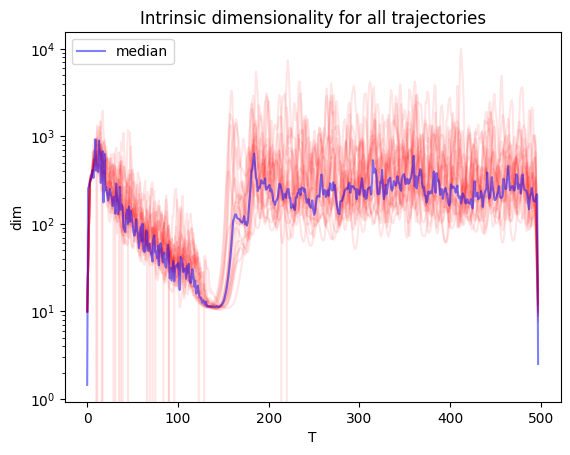

In [7]:
# smooth in x first
dims[~torch.isfinite(dims)] = 0
sdims = smooth(dims.log()).exp()
# plt.semilogy(sdims[0])
# plt.show()

assert torch.isfinite(sdims).all()

for i in range(len(dims)):
    d = sdims[i,:]
    # d[d>50000] = 0
    plt.semilogy(d, c='r', alpha=0.1)
plt.semilogy(dims.log().median(0)[0].exp(), c='b', alpha=0.5, label='median')
plt.title("Intrinsic dimensionality for all trajectories")
plt.xlabel("T")
plt.ylabel("dim")
plt.legend()
plt.show()

Above is the local intrinsic dimensionality of the data manifold; this is one requested output of the LLM (to test if it can use the features to identify at least the size of the space required for representation).

In [8]:
T=(torch.arange(dataset.shape[1]) + 1)[None,:].expand(*dataset.shape[:2])
print(T.shape, sdims.shape, dataset.shape)

torch.Size([20, 498]) torch.Size([20, 498]) torch.Size([20, 498, 1, 512, 512])


In [9]:
label=lambda t, sdim: f'{t}, {int(round(sdim.item()))}'

In [23]:
import os
import json
import torch
from torchvision.utils import save_image
from tqdm import tqdm

root = "mmai-data"
img_dir = os.path.join(root, "images")

os.makedirs(img_dir, exist_ok=True)

question = (
    "How far from an initial-condition of Gaussian noise is this flow field? "
    "What is the intrinsic dimensionality of the field? "
    "Note that the system reaches self-similarity at T=175 and the manifold "
    "dimension is then close to 32 thereafter. "
    "Format your answer as the following example (time and manifold dim) "
    "respectively: 175, 32."
)

jsonl_path = os.path.join(root, "data.jsonl")

idx = 0

with open(jsonl_path, "w") as f:

    for b in tqdm(range(dataset.shape[0]-1)): # skip last batch, we will use that for test.
        for t in range(dataset.shape[1]):

            img = dataset[b, t]

            # normalize for visualization
            img = img - img.min()
            img = img / (img.max() + 1e-8)
            # img = draw.cmap(img)

            img_path = f"images/image_{idx:06d}.jpg"
            full_img_path = os.path.join(root, img_path)

            save_image(img, full_img_path)

            answer = label(T[b, t], sdims[b, t])

            item = {
                "image": img_path,
                "question": question,
                "answer": answer
            }

            f.write(json.dumps(item) + "\n")

            idx += 1

print("Dataset written to:", root)

100%|███████████████████████████████████████████████████████████████████████████████████| 19/19 [00:45<00:00,  2.42s/it]

Dataset written to: mmai-data


In [10]:
import os
import json
import torch
from torchvision.utils import save_image
from tqdm import tqdm

root = "mmai-data-test"
img_dir = os.path.join(root, "images")

os.makedirs(img_dir, exist_ok=True)

json_path = os.path.join(root, "data.json")
jsonl_path = os.path.join(root, "data.jsonl")


In [11]:


question = (
    "How far from an initial-condition of Gaussian noise is this flow field? "
    "What is the intrinsic dimensionality of the field? "
    "Note that the system reaches self-similarity at T=175 and the manifold "
    "dimension is then close to 32 thereafter. "
    "Format your answer as the following example (time and manifold dim) "
    "respectively: 175, 32."
)



idx = 0

items = []
with open(jsonl_path, "w") as f:

    # for b in tqdm(range(dataset.shape[0]-1)): # skip last batch, we will use that for test.
    b = dataset.shape[0] - 1
    for t in range(dataset.shape[1]):

        img = dataset[b, t]

        # normalize for visualization
        img = img - img.min()
        img = img / (img.max() + 1e-8)
        # img = draw.cmap(img)

        img_path = f"images/image_{idx:06d}.jpg"
        full_img_path = os.path.join(root, img_path)

        save_image(img, full_img_path)

        answer = label(T[b, t], sdims[b, t])

        item = {
            "image": img_path,
            "question": question,
            "answer": answer
        }

        f.write(json.dumps(item) + "\n")
        items.append(item)
        idx += 1
        
with open(json_path, 'w') as json_file:
    json.dump(items, json_file, indent=4)  
    
print("Dataset written to:", root)

Dataset written to: mmai-data-test


In [12]:
test_items = items

## Questions to Answer:

*   Explain some possible issues with converting non-image data into images (even if you did not have to do so, discuss what could be some issues).

*   What are some possible issues with using visual representations of your data. Discuss some drawbacks of doing this (if you did not have to do the conversion as your data was already in the form of images, then discuss the drawbacks of converting those images to another modality like text, audio, etc.).

* Discuss the strategy you decided on how to split your data into train/test splits. Why did you settle on this? Were any other alternative splits considered?



Answer:

1. Take PDE data, in particular the matrix representation of some groups. By group theory, all groups can be represented as a subset of a symmetry group (over all elements, very large) which can be represented as a permutation matrix. So these matrix representations can then be rendered as images. Unfortunately, these images can be infinitely large (as are the matrix representations). A similar issue exists for smooth continuous flow fields; making an image is equivalent to forcing a regular discretization, which can introduce artifacts or incorrect boundary conditions.
   
2. Take audio data. To make a spectrogram, you need to choose an STFT window, which enforces a particular discretization of your data, which may be inaccurate depending on the signal and sparsity (window size). Another issue: most image encoders are x-y convolutional/shift-invariant in nature (unless you have strong positional encoding and a ViT or DiT architecture), which can be quite different --- for example, audio spectrograms have a particular directionality (time vs pitch), and for the group representation case, CNNs might not respect matrix invertibility.

3. I just left out one simulation run as a test split. In general we have too little data, so that felt most natural, and each simulation is a IID sample, so in the limit of many simulations, there is no distribution shift. Lastly, there is a large variation along each simulation in time, so it's already a hard problem for the LLM. No other splits were considered.
   

# Problem 3: Baseline Inference (10 points)

# Problem 3.1 Load the Model

Begin by running the following code to **load the base model** into memory. This step is required before training or making predictions.


In [185]:
del model
del processor
import gc
gc.collect()
torch.cuda.empty_cache()

In [13]:
import io, requests, torch
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# 1) Load model + processor (processor handles BOTH text + vision)
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
print("Model and tokenizer loaded successfully.")

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|███████████████████████████████████████████████████████████████| 824/824 [00:00<00:00, 959.21it/s]


Model and tokenizer loaded successfully.


# Problem 3.2: Run the Model on Your 4 Held-Out Images

In this step, you will use the **pre-trained** `Qwen2.5-VL-3B-Instruct` model (no fine-tuning yet) to answer questions about the **held-out images** that were **not used in training**. You will then compare the model’s predictions with the ground-truth labels and reflect on its performance.

---

## Instructions

1. **Select four held-out images**  
   Choose four test images from your dataset that were excluded from training and prompt development.

2. **Ask a consistent question**  
   Use the same question for all images, or a small set of label-aligned questions.

3. **Run the model**  
   Use the provided code cell to run inference with the pre-trained model.  

4. **Record your results**  
   For each image, collect the model’s raw output and compare it to the ground-truth label(s). If there are too many images, then show a few examples.

---

## Reflection (5–8 sentences)

After running the model on your four images, briefly discuss:
- **What worked?**  
  Which prompts or parameter settings produced better results?
- **What failed?**  
  Were there recurring failure modes (e.g., hallucinations, vague answers)?
- **Patterns in mistakes**  
  Did errors correlate with certain categories, lighting conditions, or question phrasing?

---

## Suggested Output Format

| Image ID/URL | Question | Model Output | Ground Truth | Result |
|---------------|-----------|---------------|---------------|---------|
| `img_001.jpg` | “What objects are visible?” | cat, sofa | cat, sofa | Correct |
| `img_002.jpg` | “What objects are visible?” | road, truck, sign | road, car, sign | Incorrect |

In [17]:
import io
import os
import requests
import torch
from typing import Optional, Dict, Any
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration


# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
IMAGE_URL: str = "http://images.cocodataset.org/val2017/000000039769.jpg"
QUESTION: str = question #"How does the image make you feel? Show a list of emotion labels only."
MAX_NEW_TOKENS: int = 512 #128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
DO_SAMPLE: bool = False           # set True for non-greedy decoding
TEMPERATURE: float = 0.7          # used only if DO_SAMPLE=True
TOP_P: float = 0.9                # used only if DO_SAMPLE=True
MODEL_ID: str = "Qwen/Qwen2.5-VL-3B-Instruct"
FORCE_CPU: bool = False           # force CPU even if CUDA is available
DTYPE_IF_GPU = torch.bfloat16     # prefer bfloat16 on recent GPUs/Colab
DTYPE_IF_CPU = torch.float32

def get_device_and_dtype() -> tuple[torch.device, torch.dtype, Optional[Dict[str, Any]]]:
    """Choose device/dtype and (optionally) a device_map for accelerate-style placement."""
    use_cuda = torch.cuda.is_available() and not FORCE_CPU
    device = torch.device("cuda") if use_cuda else torch.device("cpu")
    torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
    device_map = "auto" if use_cuda else None
    return device, torch_dtype, device_map


def load_image_from_url(url: str) -> Image.Image:
    """Fetch image from URL and return a RGB PIL.Image with robust fallback."""
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    try:
        return Image.open(io.BytesIO(resp.content)).convert("RGB")
    except UnidentifiedImageError:
        # Fallback: write to disk then reopen (sometimes fixes truncated headers)
        tmp_path = "temp_image.jpg"
        with open(tmp_path, "wb") as f:
            f.write(resp.content)
        img = Image.open(tmp_path).convert("RGB")
        try:
            os.remove(tmp_path)
        except Exception:
            pass
        return img


def load_from_test(n=4):
    l = len(test_items)
    idx = np.linspace(start=0, stop=l-1, num=n+1)[1:].astype(int)
    # print(test_items)
    select = [test_items[i] for i in idx]
    images = [Image.open('mmai-data-test/' + s['image']).convert("RGB") for s in select]
    paths = ['mmai-data-test/' + s['image'] for s in select]
    answers = [s["answer"] for s in select]
    return zip(paths, images, answers)

def build_chat_messages(SYSTEM_PROMPT, image: Image.Image, question: str) -> list[dict]:
    """Create a single-turn, image+text chat for Qwen-VL processors."""
    return [
        {
            "role": "system",
            "content": [
                {"type": "text", "text": SYSTEM_PROMPT}
            ],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        }
    ], []


def main(model=None, processor=None, SYSTEM_PROMPT: str = "You are a helpful assistant.", _build_chat_messages=build_chat_messages) -> None:
    device, torch_dtype, device_map = get_device_and_dtype()

    # 1) Load model + processor
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    if model is None:
        model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
            MODEL_ID,
            torch_dtype=torch_dtype,
            device_map=device_map,
        )
        print("Model and processor loaded successfully.")

    test_results = []

    for path, image, true_msg in load_from_test(6):
    
        # 2) Load image
        # image = load_image_from_url(IMAGE_URL)
    
        # 3) Build chat
        messages, images = _build_chat_messages(SYSTEM_PROMPT, image, QUESTION)
    
        # 4) Apply chat template and preprocess
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[*images, image], return_tensors="pt")
        # print(inputs)
    
        # 5) Move to the right device
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
        # 6) Generate
        gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS)
        if DO_SAMPLE:
            gen_kwargs.update(dict(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P))
    
        with torch.no_grad():
            gen_ids = model.generate(**inputs, **gen_kwargs)
    
        # 7) Decode
        out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
        # print("\n=== MODEL OUTPUT ===")
        # print(out)
        # print(true_msg)
        full_response = out.split('assistant')[-1]
        response = full_response.split('\n')[-1].strip('\n').strip('.')
        # print(out)

        def error(a, b):
            at, ad = np.array(a.split(',')).astype(int)
            bt, bd = np.array(b.split(',')).astype(int)
            return at-bt,np.log(ad/bd)
            
            
        test_results.append([path, response, true_msg, *error(response,true_msg), full_response])
        
    import pandas as pd
    import base64, io
    from IPython.display import display, HTML
    
    rows = []
    
    for image, response, true_msg, err1, err2, resp in test_results:
        img_html = f'<img src="{image}" width="80">'
    
        rows.append({
            "image": img_html,
            "response": response,
            "true": true_msg,
            "time-error (in frames)": err1,
            "dimension error (log of ratio)": err2,
            "reasoning": resp
        })
    
    df = pd.DataFrame(rows)
    display(HTML(df.to_html(escape=False)))
    

In [70]:
if __name__ == "__main__":
    main()

Loading weights: 100%|███████████████████████████████████████████████████████████████| 824/824 [00:00<00:00, 847.78it/s]


Model and processor loaded successfully.

175, 32

175, 32

175, 32

175, 32

175, 32

175, 32


,image,response,true,time-error (in frames),dimension error (log of ratio),reasoning
0,,"175, 32","83, 42",92,-0.271934,"\n175, 32"
1,,"175, 32","166, 16",9,0.693147,"\n175, 32"
2,,"175, 32","249, 260",-74,-2.094946,"\n175, 32"
3,,"175, 32","332, 469",-157,-2.684867,"\n175, 32"
4,,"175, 32","415, 418",-240,-2.569746,"\n175, 32"
5,,"175, 32","498, 10",-323,1.163151,"\n175, 32"


Clearly the pretrained model has just about no clue what I'm asking for.

Ans: What worked, failed and why.

Independent of basically everything I tried, the model doesn't generalize at all. The task is rather hard, so the model just defaults to the prior I have given (simulation time is 175 and dimension is 32) instead of estimating something based on the image. Part of the issue is likely while a human has a prior of what flow/ocean vorticity fields look like, the model has little-to-none of similar data in the original training dataset, so it can't even look for the right features.

# Problem 4: Prompt Engineering (15 points)

In this step, you'll experiment with **prompt design** to explore how different instructions influence model performance.

---

### Instructions

1. Modify the **`SYSTEM_PROMPT`** variable inside the **CHANGE ME** section of the code above.  
2. Re-run the corresponding code cell to observe how the model's responses change.  
3. Test various prompt strategies, such as:
   - Adding **examples** (few-shot prompting)
   - Restricting **answer formats** (e.g., "Answer with one word")
   - Asking for **explanations** or **step-by-step reasoning**
4. Compare your new results with the baseline output.

---

### Reflection

In your write-up, discuss:
- Which types of prompt changes improved performance?  
- Did adding context or structure help the model reason more effectively?  
- Were there any surprising or inconsistent results?


In [109]:
# let's start with reasoning and hint more
main("""We are analyzing the dynamics of quasigeostrophic flow. 
The available flow fields have time from 0 to 500 with intrinsic manifold dimension on a similar range.
In general, smooth and regular fields are closer to the Gaussian initialization (time 0) and more turbulent fields are closer to the later times.
Use your expertise in ocean and atmospheric flows to reason about the structures of the flow field in your answer, which is a best guess based on the available data.
The answer is not complete without some short reasoning, and you must restate the final values of your answer 
in the user's specified format of number, number on a new line at the end.""")

Loading weights: 100%|███████████████████████████████████████████████████████████████| 824/824 [00:00<00:00, 867.77it/s]


Model and processor loaded successfully.


,image,response,true,time-error (in frames),dimension error (log of ratio),reasoning
0,,"175, 32","83, 42",92,-0.271934,"\nGiven the information provided, it seems that the flow field is evolving towards a state closer to the Gaussian initialization by time 175, where the intrinsic dimensionality is approximately 32. Therefore, the answer is:\n\n175, 32."
1,,"175, 32","166, 16",9,0.693147,"\nThis flow field appears to be quite turbulent, suggesting it is further away from the Gaussian initialization than the smoother fields observed around time 0. Given the information provided, we can infer that this field is likely closer to the later times when turbulence is more pronounced.\n\nBased on the description, the intrinsic dimensionality of the field is approximately 32, which aligns with the observation that the system reaches self-similarity at \( T = 175 \).\n\nTherefore, the answer is:\n175, 32."
2,,"400, 32","249, 260",151,-2.094946,"\n400, 32"
3,,"400, 32","332, 469",68,-2.684867,"\n400, 32"
4,,"500, 32","415, 418",85,-2.569746,"\n500, 32"
5,,"400, 32","498, 10",-98,1.163151,"\n400, 32"


Ans: Reasoning is much better. At least now, with the expanded prompt, it can identify the right range and at least the spin-up phase (when the flow-field isn't fully developed with the right frequency spectrum).
Of course, the times are still quite off, notably it cannot tell where it is after spinup, nor anything about the dimensionality.

In [20]:
def load_from_train(n=5): 
    lines = open('mmai-data/data.jsonl', "r").readlines()
    idx = np.linspace(start=0, stop=len(lines)-1, num=n).astype(int)
    lines = [lines[i] for i in idx]
    select = [json.loads(l) for l in lines]
    
    images = [Image.open('mmai-data/' + s['image']).convert("RGB") for s in select]
    answers = [s["answer"] for s in select] 
    
    return images, answers
    
def build_chat_messages2(SYSTEM_PROMPT, image: Image.Image, question: str):
    N = 48
    images, answers = load_from_train(N)
    ind = torch.randperm(N)
    images = [images[i] for i in ind]
    answers = [answers[i] for i in ind]
    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}],
        }
    ]

    # few-shot examples
    for im, ans in zip(images, answers):

        messages.append({
            "role": "user",
            "content": [
                {"type": "image", "image": im},
                {"type": "text", "text": question},
            ],
        })

        messages.append({
            "role": "assistant",
            "content": [{"type": "text", "text": ans}],
        })

    # actual query
    messages.append({
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question},
        ],
    })

    return messages, images

In [184]:
main("""We are analyzing quasigeostrophic turbulence.
Early times:
smooth flow with few vortices.
Middle times:
vortex merging and filament formation.
Late times:
many thin filaments and small vortices. 
The flow eventually becomes self-similar and the intrinsic
manifold dimension saturates.
Use the visual structure of the field to estimate the stage
of turbulence; provide your best guess. Use previous images to inform.""", _build_chat_messages=build_chat_messages2)
# used GPT assistance to get a better prompt after trying a couple that didn't work well

Loading weights: 100%|███████████████████████████████████████████████████████████████| 824/824 [00:00<00:00, 861.22it/s]


Model and processor loaded successfully.


,image,response,true,time-error (in frames),dimension error (log of ratio),reasoning
0,,"102, 10","83, 42",19,-1.435085,"\n102, 10"
1,,"198, 11","166, 16",32,-0.374693,"\n198, 11"
2,,"249, 10","249, 260",0,-3.258097,"\n249, 10"
3,,"342, 11","332, 469",10,-3.752707,"\n342, 11"
4,,"222, 10","415, 418",-193,-3.732896,"\n222, 10"
5,,"228, 10","498, 10",-270,0.000000,"\n228, 10"


Ans: Few-shot is much better. We now have a good idea of the spinup time frames (though still off on exact times after spinup). The dimensionality is still completely wrong (surprising that it's still too hard a question).

Added structure didn't seem to help too much; in fact, reasoning required a variable token length, so the fixed (numeric) output structure conflicted with the reasoning sequence (so reasoning was removed in the final prompt).
Also, the few-shot model required a random shuffle of inputs, to avoid coarse pattern-matching that ignored the image entirely (it just output a constant rise in the simulation time).

# Problem 5: LoRA Fine-Tuning (20 points)

In this step, you'll fine-tune a **Vision-Language Model (VLM)** using **LoRA (Low-Rank Adaptation)** on your dataset.  
This exercise will help you understand how different hyperparameters influence performance, GPU memory usage, and output quality.

### Instructions

Run the code block below.  
If you followed the **`mmai-data`** example, the script should automatically detect and load your training dataset.

### Adjust and experiment with

- **Number of epochs** (`NUM_EPOCHS`)
- **Learning rate** (`LR`)
- **Batch size per device** (`BSZ_PER_DEV`)
- **Gradient accumulation steps** (`GRAD_ACCUM`)
- **Evaluation split ratio** (`EVAL_SPLIT`)
- **Random seed** (`SEED`)
- **Sequence length** (`MAX_SEQ_LEN`)
- **Image resolution** (`SHORTEST_EDGE`)
- **LoRA rank** (`LORA_R`)
- **LoRA alpha** (`LORA_ALPHA`)
- **LoRA dropout** (`LORA_DROPOUT`)
- **LoRA target modules** (`LORA_TARGET`)

---

```python
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# (Modify the parameters below in the Colab cell)

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

### Q&A

**Q:** What should I do if I encounter an out-of-memory issue?  
**A:** Your image might be too large. Try resizing it by adding the following line back into your code and experiment with different pixel values:

```python
img.thumbnail((128, 128))  # NOTE: If you run into an out-of-memory error, try adding this line back.
```


In [190]:
!uv pip install peft

Using Python 3.12.12 environment at: /orcd/home/002/a1744874/ml/courses/.venv
Resolved 55 packages in 2.19s                                        
Prepared 1 package in 1.02s                                              
Installed 1 package in 266ms                                
 + peft==0.18.1


In [42]:
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

# Environment hygiene
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 1
LR: float        = 1e-4
BSZ_PER_DEV: int = 8
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 512 #288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
# Paths
DATA_JSONL: str  = "mmai-data/data.jsonl"
OUTPUT_DIR: str  = "qwen2_5_vl_lora_fp16_t4"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "cache_images"
IMAGE_TIMEOUT: int = 15

# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 16 #4
LORA_ALPHA: int      = 8
LORA_DROPOUT: float  = 0.005
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32

In [43]:
# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Demo data (create if missing)
# --------------------
def _ensure_sample_data(path: str):
    # Ensure parent directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
      display(HTML(
          "<div style='color:white; background-color:#2e7d32; padding:10px; border-radius:6px;'>"
          "<strong>Using custom training data:</strong> "
          f"Loaded dataset from <code>{path}</code>. "
          "Proceeding with user-provided images and JSONL file."
          "</div>"
      ))
      return

    demo = [
        {
            "image": "http://images.cocodataset.org/val2017/000000039769.jpg",
            "question": "List objects you see.",
            "answer": "cat, sofa, blanket, remote, cushion, tail, paw"
        },
        {
            "image": "http://images.cocodataset.org/val2017/000000001532.jpg",
            "question": "List objects you see.",
            "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"
        },
    ]
    with open(path, "w") as f:
        for r in demo: f.write(json.dumps(r) + "\n")

    # Print a red warning box (works in Colab/Jupyter)
    display(HTML(
        "<div style='color:white; background-color:#b71c1c; padding:10px; border-radius:6px;'>"
        "<strong>Warning:</strong> No dataset found — using built-in <code>sample data</code> (2 demo images). "
        "Please replace with your own dataset of at least 20 images for training."
        "</div>"
    ))

_ensure_sample_data(DATA_JSONL)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

full_ds = JsonlVisionLangDataset(DATA_JSONL)

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
val_idx = set(idx[:n_val])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

class ListDataset(Dataset):
    def __init__(self, data_list): self.data_list = data_list
    def __len__(self): return len(self.data_list)
    def __getitem__(self, i): return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
BASE_DIR = os.path.dirname(DATA_JSONL)

def cache_image(url_or_path: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the JSONL file
    candidate = url_or_path
    if not os.path.isabs(candidate):
        candidate = os.path.join(BASE_DIR, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {BASE_DIR}/"
        )
    return candidate


for ex in train_data: ex["image"] = cache_image(ex["image"])
for ex in val_data:   ex["image"] = cache_image(ex["image"])

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    # img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img


# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
device_map = "auto" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

Loading weights: 100%|███████████████████████████████████████████████████████████████| 824/824 [00:03<00:00, 263.29it/s]


In [ ]:
# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,   # v5 may pass this
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # keep fp16 path if available

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    max_steps=2000,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="no",              # keep simple; eval loop optional
    save_strategy="steps",
    save_steps=10_000,

    fp16=False, bf16=use_cuda,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

In [48]:
trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)

Step,Training Loss
1,0.318625
2,0.321620
3,0.334054
4,0.310619
5,0.320059
6,0.323536
7,0.324883
8,0.312495
9,0.322927
10,0.333222


Training complete. LoRA adapters saved to: qwen2_5_vl_lora_fp16_t4


# **Questions to answer:**

1. Report the settings you used to get the best model.
  
2. Which hyperparameters did you find have the most impact in the model’s performance?

3. Why do you think that is?



See above for the best settings. Interestingly, my model stagnated early on (have run the above cell multiple times; it starts at about 7 in loss).

Likely the cross-entropy loss is not best---I should use a MSE loss and a continuous output variable.
Learning rate is obviously the most impactful, though I found the 1e-4 to be best (nice standard value).
I increased LoRA rank and batchsize to improve stability (achieved convergence much faster too), but did not get anything in accuracy.

One note; with smaller image sizes (shortest_edge) and less tokens for reasoning, the model performed quite badly. Since the images are mostly texture (vorticity shapes), the lower resolution seems to have destroyed performance. 

# Problem 6: Post-Training Evaluation (30 points)

# Problem 6.1 Load the Trained LoRA Adapter

Once your fine-tuning is complete, load the trained **LoRA adapters** back onto the original model to perform inference, that is, to generate predictions or analyze new images.

Simply run the code in the next code block.  
It will automatically attach your fine-tuned LoRA weights and prepare the model for evaluation.


In [49]:

# --------------------
# Inference with adapters
# --------------------
from peft import PeftModel
base = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(base, OUTPUT_DIR)
ft_model.eval()
print("LoRA adapters loaded. Ready for inference.")

Loading weights: 100%|███████████████████████████████████████████████████████████████| 824/824 [00:02<00:00, 275.36it/s]


LoRA adapters loaded. Ready for inference.


# Problem 6.2 Re-Test on Held-Out Images

Re-test the same **held-out images** used in your baseline evaluation.

Compare the **pre-trained** (in Step 2.2) and **fine-tuned** model outputs:

- Which questions showed improvement?  
- Did LoRA fine-tuning correct any earlier mistakes?  
- Were any new errors or biases introduced after fine-tuning?

Document your observations and include examples where possible.


In [50]:
main(model=ft_model, SYSTEM_PROMPT="You are a helpful assistant.")

,image,response,true,time-error (in frames),dimension error (log of ratio),reasoning
0,,"196, 408","83, 42",113,2.273598,"\n196, 408"
1,,"196, 408","166, 16",30,3.238678,"\n196, 408"
2,,"196, 408","249, 260",-53,0.450586,"\n196, 408"
3,,"406, 189","332, 469",74,-0.908856,"\n406, 189"
4,,"194, 106","415, 418",-221,-1.372042,"\n194, 106"
5,,"406, 189","498, 10",-92,2.939162,"\n406, 189"


In [51]:
main(model=ft_model, SYSTEM_PROMPT="""We are analyzing quasigeostrophic turbulence.
Early times:
smooth flow with few vortices.
Middle times:
vortex merging and filament formation.
Late times:
many thin filaments and small vortices. 
The flow eventually becomes self-similar and the intrinsic
manifold dimension saturates.
Use the visual structure of the field to estimate the stage
of turbulence; provide your best guess. Use previous images to inform.""", _build_chat_messages=build_chat_messages2)

,image,response,true,time-error (in frames),dimension error (log of ratio),reasoning
0,,"106, 11","83, 42",23,-1.339774,"\n106, 11"
1,,"280, 1237","166, 16",114,4.347856,"\n280, 1237"
2,,"295, 377","249, 260",46,0.371564,"\n295, 377"
3,,"206, 107","332, 469",-126,-1.477774,"\n206, 107"
4,,"306, 107","415, 418",-109,-1.362653,"\n306, 107"
5,,"395, 175","498, 10",-103,2.862201,"\n395, 175"


Actually much better --- the timestamps are closer now and we have a large but constant offset rather than a trend in the error. Even the dimensionality is closer (though for some reason the model greatly overestimates the complexity of the smooth field during spinup).

For some reason, the model still requires a couple few-shot examples...likely again because the task is so different than normal VLM tasks. My best guess is the examples help precondition the autoregressive latent.

# Problem 7: Final Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. What concept did you find the most interesting?
2. Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more?

Ans:

1. I liked the questions at the beginning (though a bit open-ended with respect to the readings). I have seen a lot of recent discussion about distribution separation across my classes, so it was nice to tie them together a little.
2. Not much, unfortunately. I had high hopes for the LLM: actually, there are papers that tokenize fluid flow and use an LLM to predict it, so it could have gone quite well. Basically, this assignment helped confirm that the standard VLMs aren't quite enough for complex fluid flows, because of the amount of difficulty they had with some basic questions (that are needed to even set up the prediction or generation process).
3. Probably the architecture. A lot of these models (like this VLM) are essentially a black-box as far as the assignment and multimodal aspects are concerned---which is definitely not the case for practical problems. There's still too much a disconnect with practice for me. I would like to understand these models at the level of the attention head, which is actually doable for most smaller models. Maybe we could do an assignment where we inspect the saliency maps of a VLM or something and see where the fusion happens, how, and why... (like attention heat maps, or even the famous CNN visualization paper)?